- 고정 hu window확정 - voxel intensity 정규화 O
- source(데이터종류)별 데이터 개수 확인 O
- source별 slice수 확인 O
- label class(t11/t12)포함 여부 확인 및 T11/T12 포함 volume 선별
- volume과 label 매칭 확인 
- (t11/t12)label foreground(라벨이 너무 작거나 없는 volume) 비율 확인 
- voxel spacing 분석 및 정규화

1. Source별 volume 개수 확인 O
2. Source별 slice 수 확인 O
3. Voxel intensity percentile 분석 후 고정 HU window 설정 O
4. Volume-label 매칭 확인 O
5. T11/T12 label 포함 여부 확인 O
7. T11/T12 voxel count 및 bounding box 크기 확인
8. T11/T12 z-slice 위치 및 경계 잘림 여부 확인
9. Source별 T11/T12 overlay 시각화 QA
10. 최종 학습 데이터 후보 선정

In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_ROOT = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data")
VOLUME_ROOT = DATA_ROOT / "volumes"
LABEL_ROOT = DATA_ROOT / "labels"

SOURCES = ["COLONOG", "COVID-19", "MSD-T10"]

## source 별 volume 개수 확인

,n_volumes
source,
COLONOG,784
COVID-19,40
MSD-T10,150


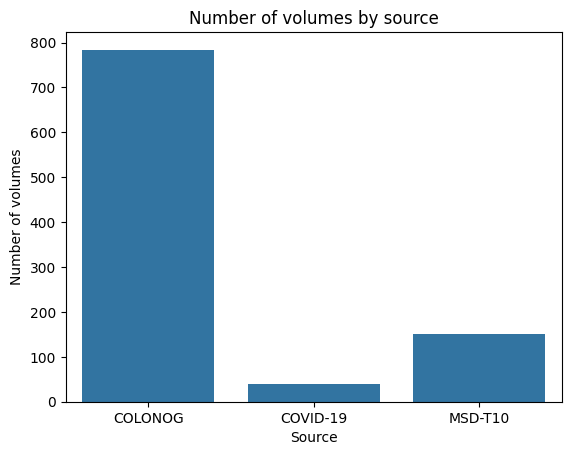

In [2]:
volume_rows = []

for source in SOURCES:
    source_dir = VOLUME_ROOT / source
    files = sorted(source_dir.glob("*.nii.gz"))

    for path in files:
        volume_rows.append({
            "source": source,
            "patient_id": path.name.replace(".nii.gz", ""),
            "file_name": path.name,
            "volume_path": path,
        })

df_volumes = pd.DataFrame(volume_rows)

display(df_volumes.groupby("source").size().rename("n_volumes").to_frame())

sns.countplot(data=df_volumes, x="source", order=SOURCES)
plt.title("Number of volumes by source")
plt.xlabel("Source")
plt.ylabel("Number of volumes")
plt.show()

## source 별 slice 수 확인

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
COLONOG,784.0,542.075255,57.818920,85.0,503.75,542.0,579.00,736.0
COVID-19,40.0,92.575000,77.176085,51.0,62.75,67.0,71.00,361.0
MSD-T10,150.0,477.793333,265.172485,42.0,237.50,467.0,693.25,1026.0


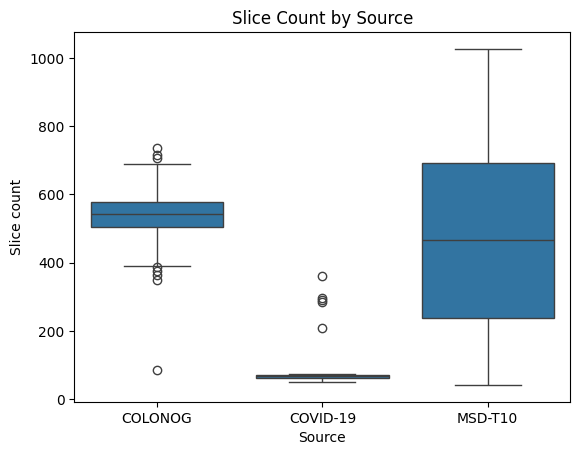

In [3]:
slice_rows = []

for row in df_volumes.itertuples(index=False):
    img = nib.load(row.volume_path)

    slice_rows.append({
        "source": row.source,
        "patient_id": row.patient_id,
        "file_name": row.file_name,
        "shape": img.shape,
        "slice_count": img.shape[2],
    })

df_slices = pd.DataFrame(slice_rows)

display(df_slices.groupby("source")["slice_count"].describe())

sns.boxplot(data=df_slices, x="source", y="slice_count", order=SOURCES)
plt.title("Slice Count by Source")
plt.xlabel("Source")
plt.ylabel("Slice count")
plt.show()

## label 파일 매칭 확인

In [4]:
def find_label_path(volume_path):
    rel = volume_path.relative_to(VOLUME_ROOT)
    label_dir = LABEL_ROOT / rel.parent
    stem = volume_path.name.replace(".nii.gz", "")

    candidates = [
        label_dir / f"{stem}_seg.nii.gz",
        label_dir / volume_path.name,
        label_dir / f"{stem}.nii.gz",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


label_match_rows = []

for row in df_volumes.itertuples(index=False):
    label_path = find_label_path(row.volume_path)

    label_match_rows.append({
        "source": row.source,
        "patient_id": row.patient_id,
        "file_name": row.file_name,
        "volume_path": row.volume_path,
        "label_path": label_path,
        "label_exists": label_path is not None,
    })

df_label_match = pd.DataFrame(label_match_rows)

display(pd.crosstab(df_label_match["source"], df_label_match["label_exists"], margins=True))
display(df_label_match[df_label_match["label_exists"] == False])

label_exists,True,All
source,,
COLONOG,784,784
COVID-19,40,40
MSD-T10,150,150
All,974,974


,source,patient_id,file_name,volume_path,label_path,label_exists


## label 정보 한 번에 계산

In [5]:
label_summary_rows = []

for idx, row in enumerate(
    df_label_match[df_label_match["label_exists"]].itertuples(index=False),
    start=1
):
    seg = np.asanyarray(nib.load(row.label_path).dataobj)

    values, counts = np.unique(seg, return_counts=True)
    values = values.astype(int)
    counts = counts.astype(int)

    count_by_label = dict(zip(values, counts))

    total_voxels = int(seg.size)
    foreground_voxels = int(total_voxels - count_by_label.get(0, 0))
    foreground_ratio = foreground_voxels / total_voxels

    label_summary_rows.append({
        "source": row.source,
        "patient_id": row.patient_id,
        "file_name": row.file_name,
        "label_path": row.label_path,
        "label_values": tuple(values),
        "n_labels": len(values),
        "foreground_voxels": foreground_voxels,
        "total_voxels": total_voxels,
        "foreground_ratio": foreground_ratio,
        "count_by_label": count_by_label,
    })

    if idx % 25 == 0:
        print(f"Processed {idx}")

df_label_summary = pd.DataFrame(label_summary_rows)

display(df_label_summary.head())

Processed 25
Processed 50
Processed 75
Processed 100
Processed 125
Processed 150
Processed 175
Processed 200
Processed 225
Processed 250
Processed 275
Processed 300
Processed 325
Processed 350
Processed 375
Processed 400
Processed 425
Processed 450
Processed 475
Processed 500
Processed 525
Processed 550
Processed 575
Processed 600
Processed 625
Processed 650
Processed 675
Processed 700
Processed 725
Processed 750
Processed 775
Processed 800
Processed 825
Processed 850
Processed 875
Processed 900
Processed 925
Processed 950


,source,patient_id,file_name,label_path,label_values,n_labels,foreground_voxels,total_voxels,foreground_ratio,count_by_label
0,COLONOG,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001.nii.gz,C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\...,"(0, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24)",12,795060,158334976,0.005021,"{0: 157539916, 14: 36, 15: 4879, 16: 55307, 17..."
1,COLONOG,1.3.6.1.4.1.9328.50.4.0002,1.3.6.1.4.1.9328.50.4.0002.nii.gz,C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\...,"(0, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23...",13,1293312,166985728,0.007745,"{0: 165692416, 13: 702, 14: 24041, 15: 97298, ..."
2,COLONOG,1.3.6.1.4.1.9328.50.4.0003,1.3.6.1.4.1.9328.50.4.0003.nii.gz,C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\...,"(0, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21...",15,1289478,173801472,0.007419,"{0: 172511994, 11: 17, 12: 3238, 13: 60585, 14..."
3,COLONOG,1.3.6.1.4.1.9328.50.4.0004,1.3.6.1.4.1.9328.50.4.0004.nii.gz,C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\...,"(0, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)",11,919756,136314880,0.006747,"{0: 135395124, 16: 25, 17: 27302, 18: 82960, 1..."
4,COLONOG,1.3.6.1.4.1.9328.50.4.0005,1.3.6.1.4.1.9328.50.4.0005.nii.gz,C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\...,"(0, 16, 17, 18, 19, 20, 21, 22, 23, 24)",10,1251775,105119744,0.011908,"{0: 103867969, 16: 2209, 17: 90545, 18: 146276..."


In [ ]:
df_label_summary.to_pickle("label_summary_by_volume.pkl")


In [2]:
import pandas as pd
df_label_summary = pd.read_pickle("label_summary_by_volume.pkl")

## label class 종류 확인

In [7]:
display(df_label_summary.groupby("source")["n_labels"].describe())

for source in SOURCES:
    source_values = sorted(set().union(
        *df_label_summary[df_label_summary["source"] == source]["label_values"]
    ))
    print(source, source_values)

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
COLONOG,784.0,11.165816,1.516383,6.0,10.0,11.0,12.0,16.0
COVID-19,40.0,16.050000,1.153590,14.0,15.0,16.0,17.0,19.0
MSD-T10,150.0,14.840000,4.628595,8.0,11.0,12.0,20.0,22.0


COLONOG [np.int64(0), np.int64(1), np.int64(6), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
COVID-19 [np.int64(0), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]
MSD-T10 [np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
